# IMPORT LIBRARY

In [ ]:
# Install Library
!pip install category_encoders
!pip install catboost
!pip install imblearn
!pip install category_encoders
!pip install xgboost
!pip install lightgbm

In [ ]:
# Library Olah Data
import pandas as pd
import numpy as np

# Library Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Library PREPROCESSING & ML
import sklearn as sk
import category_encoders as ce
from sklearn.model_selection import train_test_split ,KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import *
from sklearn.ensemble import *
from catboost import CatBoostClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    auc,
    f1_score
)
from imblearn.over_sampling import SMOTE


# LIBRARY LOAD DATASET GDRIVE
import gdown as gd


# LOAD DATASET

## LOAD DATASET TRAINING


In [ ]:
# Buat Path dan ID
name_path_train = "training_dataset.csv"
id_path_train = "1xQ5tDWTNGiwfKLH8C6iwkqf-hyk3dbt-"

# Download Dataset
gd.download(f"https://drive.google.com/uc?id={id_path_train}", name_path_train, quiet=False)


Downloading...
From: https://drive.google.com/uc?id=1xQ5tDWTNGiwfKLH8C6iwkqf-hyk3dbt-
To: /content/training_dataset.csv
100%|██████████| 2.94M/2.94M [00:00<00:00, 34.1MB/s]


'training_dataset.csv'

In [ ]:
# BACA DATASET & LOAD
df_train_raw = pd.read_csv(name_path_train)
df_train_raw

,customer_number,usia,pekerjaan,status_perkawinan,pendidikan,gagal_bayar_sebelumnya,pinjaman_rumah,pinjaman_pribadi,jenis_kontak,bulan_kontak_terakhir,...,hari_sejak_kontak_sebelumnya,jumlah_kontak_sebelumnya,hasil_kampanye_sebelumnya,tingkat_variasi_pekerjaan,indeks_harga_konsumen,indeks_kepercayaan_konsumen,suku_bunga_euribor_3bln,jumlah_pekerja,pulau,berlangganan_deposito
0,531036,63,sosial media specialis,menikah,Pendidikan Tinggi,no,yes,no,cellular,jul,...,999,0,nonexistent,-1.7,94.215,-40.3,0.885,4991.6,Papua,1
1,999241,43,teknisi,menikah,Pendidikan Tinggi,no,yes,no,cellular,nov,...,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,Sulawesi,0
2,995002,29,sosial media specialis,lajang,Pendidikan Tinggi,no,yes,yes,cellular,jul,...,999,0,nonexistent,1.4,93.918,-42.7,4.958,5228.1,Papua,0
3,932750,40,pekerja kasar,menikah,SMA,no,no,no,telephone,may,...,999,0,nonexistent,1.1,93.994,-36.4,4.859,5191.0,Sumatera,1
4,684699,40,sosial media specialis,lajang,Pendidikan Tinggi,no,no,no,cellular,aug,...,999,0,nonexistent,1.4,93.444,-36.1,4.964,5228.1,Bali,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22911,680377,32,teknisi,menikah,Diploma,no,yes,no,cellular,aug,...,999,0,nonexistent,1.4,93.444,-36.1,4.967,5228.1,Kalimantan,0
22912,505429,30,mahasiswa,lajang,Diploma,no,no,no,telephone,sep,...,999,0,nonexistent,-1.1,94.199,-37.5,0.880,4963.6,Bali,0
22913,308952,29,manajer,lajang,SMA,no,yes,no,cellular,jul,...,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,NTT,0
22914,865813,52,entrepreneur,menikah,Tidak Tamat SD,unknown,yes,no,telephone,jun,...,999,0,nonexistent,1.4,94.465,-41.8,4.960,5228.1,NTB,0


## LOAD DATASET VALIDASI

In [ ]:
# Buat Path dan ID
name_path_val = "validation_dataset.csv"
id_path_val = "10krAC2wQCM5b9pr_VrPO5piih9gSNELO"

# Load Dataset
gd.download(f"https://drive.google.com/uc?id={id_path_val}", name_path_val, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=10krAC2wQCM5b9pr_VrPO5piih9gSNELO
To: /content/validation_dataset.csv
100%|██████████| 726k/726k [00:00<00:00, 25.3MB/s]


'validation_dataset.csv'

In [ ]:
df_raw_val = pd.read_csv(name_path_val)
X_valid = df_raw_val
X_valid

,customer_number,usia,pekerjaan,status_perkawinan,pendidikan,gagal_bayar_sebelumnya,pinjaman_rumah,pinjaman_pribadi,jenis_kontak,bulan_kontak_terakhir,...,jumlah_kontak_kampanye_ini,hari_sejak_kontak_sebelumnya,jumlah_kontak_sebelumnya,hasil_kampanye_sebelumnya,tingkat_variasi_pekerjaan,indeks_harga_konsumen,indeks_kepercayaan_konsumen,suku_bunga_euribor_3bln,jumlah_pekerja,pulau
0,445420,35,penyedia jasa,menikah,SMA,no,yes,yes,cellular,jul,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.960,5228.1,Jawa
1,585604,52,teknisi,lajang,Diploma,unknown,no,no,telephone,may,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.860,5191.0,Papua
2,888824,37,pekerja kasar,menikah,SMP,unknown,yes,no,telephone,may,...,3,999,0,nonexistent,1.1,93.994,-36.4,4.856,5191.0,Bali
3,816820,51,pengangguran,menikah,Diploma,no,no,no,telephone,may,...,3,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,Sumatera
4,542716,45,teknisi,cerai,SMA,no,yes,no,cellular,may,...,1,999,1,failure,-1.8,92.893,-46.2,1.327,5099.1,Sumatera
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5724,782072,51,pekerja kasar,menikah,Tidak Tamat SD,no,yes,no,telephone,jun,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.961,5228.1,Kalimantan
5725,116371,30,pekerja kasar,menikah,SMP,no,yes,yes,telephone,may,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,Sulawesi
5726,773759,45,pekerja kasar,menikah,SMP,unknown,yes,no,telephone,may,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,NTB
5727,612330,60,teknisi,menikah,Diploma,unknown,no,no,telephone,jul,...,15,999,0,nonexistent,1.4,93.918,-42.7,4.961,5228.1,Papua


# EDA (EXPLORATORY DATA ANALISIS)

## STATISTIK DESKRIPTIF

In [ ]:
df_train_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22916 entries, 0 to 22915
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_number               22916 non-null  int64  
 1   usia                          22916 non-null  int64  
 2   pekerjaan                     22916 non-null  object 
 3   status_perkawinan             22916 non-null  object 
 4   pendidikan                    22916 non-null  object 
 5   gagal_bayar_sebelumnya        22916 non-null  object 
 6   pinjaman_rumah                22916 non-null  object 
 7   pinjaman_pribadi              22916 non-null  object 
 8   jenis_kontak                  22916 non-null  object 
 9   bulan_kontak_terakhir         22916 non-null  object 
 10  hari_kontak_terakhir          22916 non-null  object 
 11  jumlah_kontak_kampanye_ini    22916 non-null  int64  
 12  hari_sejak_kontak_sebelumnya  22916 non-null  int64  
 13  j

In [ ]:
df_train_raw.describe()

,customer_number,usia,jumlah_kontak_kampanye_ini,hari_sejak_kontak_sebelumnya,jumlah_kontak_sebelumnya,tingkat_variasi_pekerjaan,indeks_harga_konsumen,indeks_kepercayaan_konsumen,suku_bunga_euribor_3bln,jumlah_pekerja,berlangganan_deposito
count,22916.000000,22916.000000,22916.000000,22916.000000,22916.000000,22916.000000,22916.000000,22916.000000,22916.000000,22916.000000,22916.000000
mean,550930.993193,40.016233,2.561878,962.210377,0.170143,0.077915,93.576541,-40.485717,3.617890,5166.773124,0.114069
std,259909.889175,10.438059,2.794178,187.566774,0.490611,1.576176,0.580586,4.641091,1.737591,72.479698,0.317902
min,100108.000000,17.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000
25%,325755.000000,32.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000
50%,553139.000000,38.000000,2.000000,999.000000,0.000000,1.100000,93.876000,-41.800000,4.857000,5191.000000,0.000000
75%,777157.500000,47.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000
max,999997.000000,98.000000,42.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000


## ANOMALY VALUES

In [ ]:

cat_cols = df_train_raw.select_dtypes(include='object').columns
cat_cols


Index(['pekerjaan', 'status_perkawinan', 'pendidikan',
       'gagal_bayar_sebelumnya', 'pinjaman_rumah', 'pinjaman_pribadi',
       'jenis_kontak', 'bulan_kontak_terakhir', 'hari_kontak_terakhir',
       'hasil_kampanye_sebelumnya', 'pulau'],
      dtype='object')

In [ ]:
num_cols = df_train_raw.select_dtypes(include='number').columns
num_cols

Index(['customer_number', 'usia', 'jumlah_kontak_kampanye_ini',
       'hari_sejak_kontak_sebelumnya', 'jumlah_kontak_sebelumnya',
       'tingkat_variasi_pekerjaan', 'indeks_harga_konsumen',
       'indeks_kepercayaan_konsumen', 'suku_bunga_euribor_3bln',
       'jumlah_pekerja', 'berlangganan_deposito'],
      dtype='object')

In [ ]:
# DUPLICATED VALUES
# Untuk pengecekan nilai duplikat
df_train_raw.duplicated().sum()


np.int64(0)

In [ ]:
# MISSING VALUES
# Untuk pengecekan nilai NaN atau nilai kosong
df_train_raw.isnull().sum()


,0
customer_number,0
usia,0
pekerjaan,0
status_perkawinan,0
pendidikan,0
gagal_bayar_sebelumnya,0
pinjaman_rumah,0
pinjaman_pribadi,0
jenis_kontak,0
bulan_kontak_terakhir,0


In [ ]:
# Cari Nilai Unique
df_train_raw.nunique()

,0
customer_number,22916
usia,78
pekerjaan,12
status_perkawinan,4
pendidikan,8
gagal_bayar_sebelumnya,3
pinjaman_rumah,3
pinjaman_pribadi,3
jenis_kontak,2
bulan_kontak_terakhir,10


In [ ]:
df_train_raw['jumlah_kontak_sebelumnya'].value_counts()

,count
jumlah_kontak_sebelumnya,
0,19836
1,2495
2,418
3,115
4,41
5,8
6,2
7,1


In [ ]:
# Nilai Quartil
Q1 =  df_train_raw[num_cols].quantile(0.25)
Q3 =  df_train_raw[num_cols].quantile(0.75)

# Nilai IQR
IQR = Q3 - Q1

# Batasan IQR
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Cari Outliers
outlier = (( df_train_raw[num_cols] < lower_bound) | ( df_train_raw[num_cols] > upper_bound))
outlier

,customer_number,usia,jumlah_kontak_kampanye_ini,hari_sejak_kontak_sebelumnya,jumlah_kontak_sebelumnya,tingkat_variasi_pekerjaan,indeks_harga_konsumen,indeks_kepercayaan_konsumen,suku_bunga_euribor_3bln,jumlah_pekerja,berlangganan_deposito
0,False,False,False,False,False,False,False,False,False,False,True
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,True
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
22911,False,False,False,False,False,False,False,False,False,False,False
22912,False,False,False,False,False,False,False,False,False,False,False
22913,False,False,False,False,False,False,False,False,False,False,False
22914,False,False,False,False,False,False,False,False,False,False,False


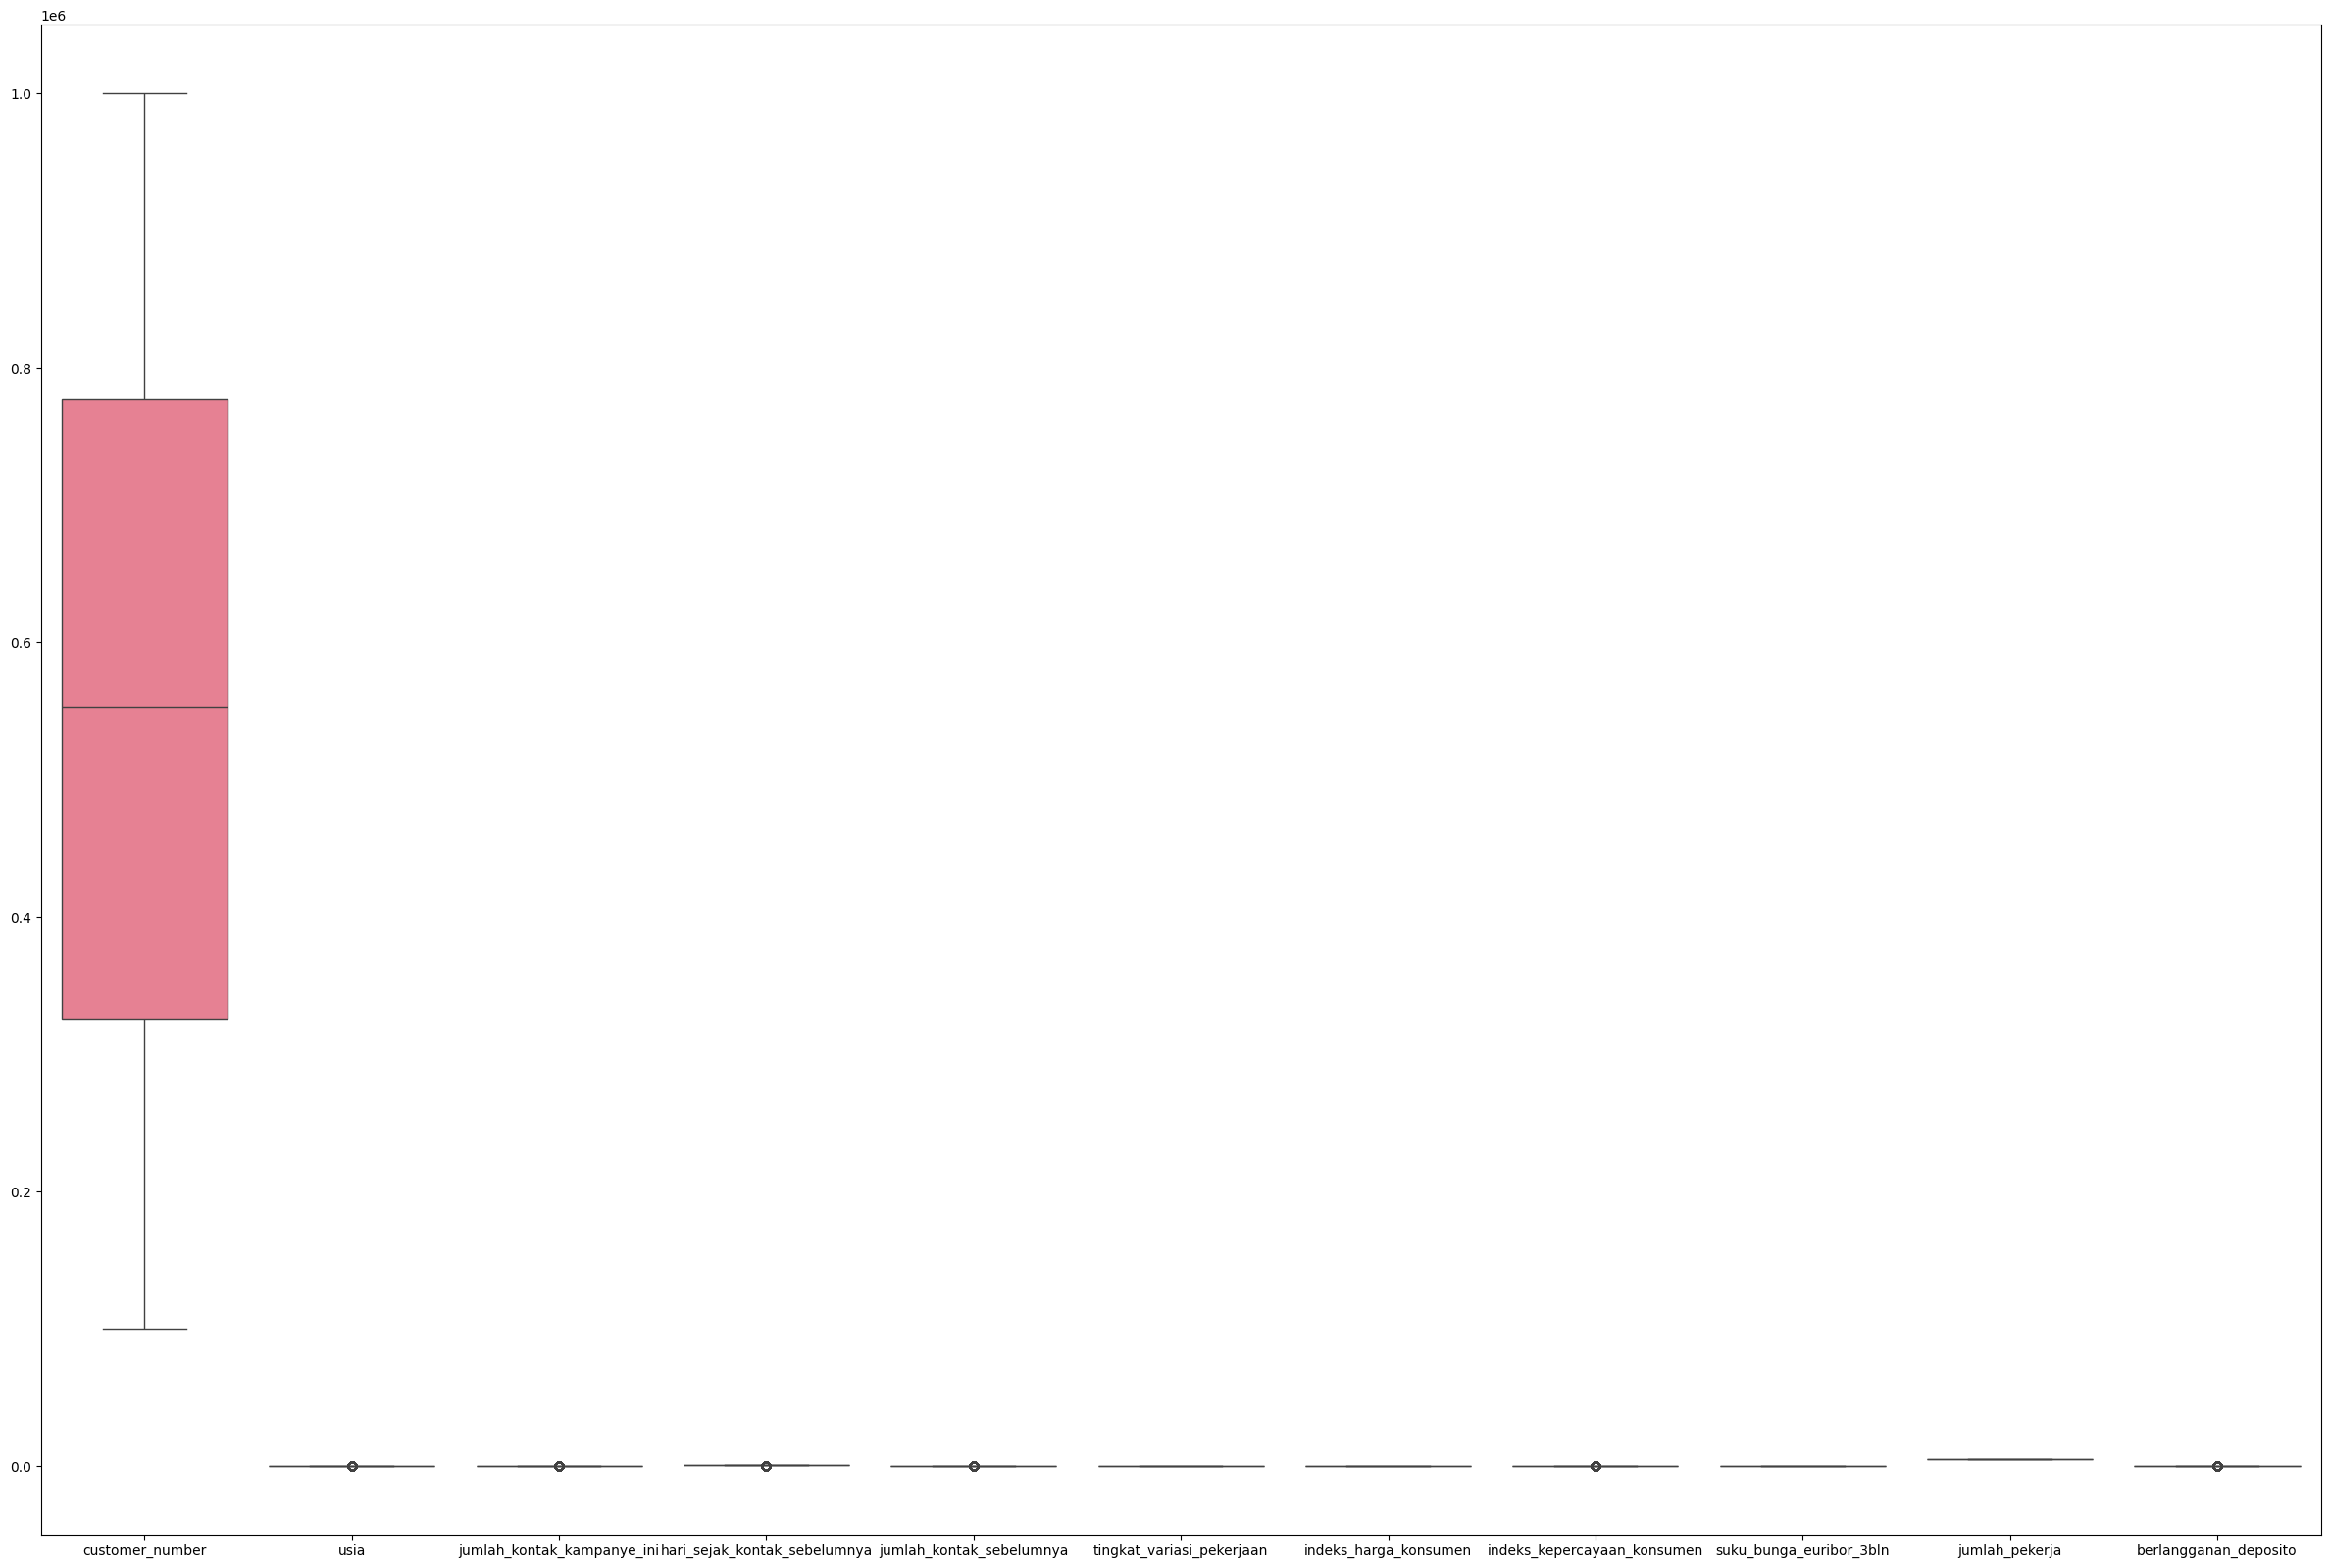

In [ ]:
plt.figure(figsize=(30, 20))
sns.boxplot(data=df_train_raw)
plt.show()

## PERSEBARAN DATA

In [ ]:
kurtosis_df = df_train_raw[num_cols].kurtosis()
kurtosis_df

,0
customer_number,-1.202363
usia,0.729022
jumlah_kontak_kampanye_ini,35.736595
hari_sejak_kontak_sebelumnya,22.036895
jumlah_kontak_sebelumnya,20.297158
tingkat_variasi_pekerjaan,-1.062946
indeks_harga_konsumen,-0.818131
indeks_kepercayaan_konsumen,-0.348961
suku_bunga_euribor_3bln,-1.413016
jumlah_pekerja,-0.018863


In [ ]:
skew_df = df_train_raw[num_cols].skew()
skew_df

,0
customer_number,-0.007375
usia,0.770997
jumlah_kontak_kampanye_ini,4.808911
hari_sejak_kontak_sebelumnya,-4.902505
jumlah_kontak_sebelumnya,3.849091
tingkat_variasi_pekerjaan,-0.724622
indeks_harga_konsumen,-0.250087
indeks_kepercayaan_konsumen,0.314411
suku_bunga_euribor_3bln,-0.705541
jumlah_pekerja,-1.040202


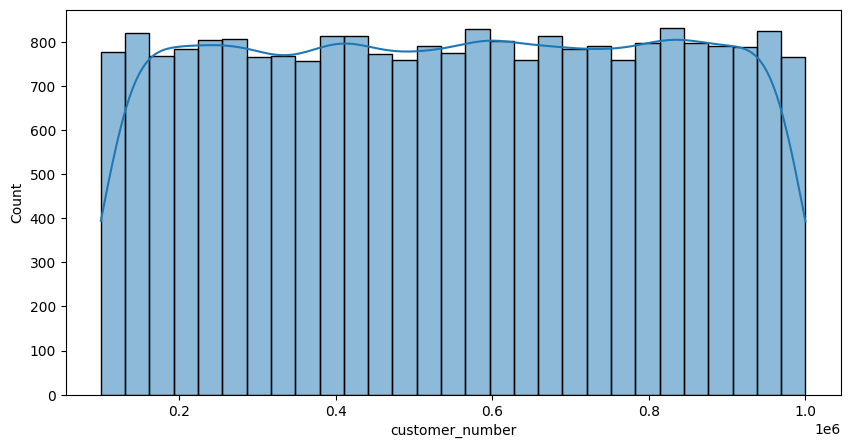

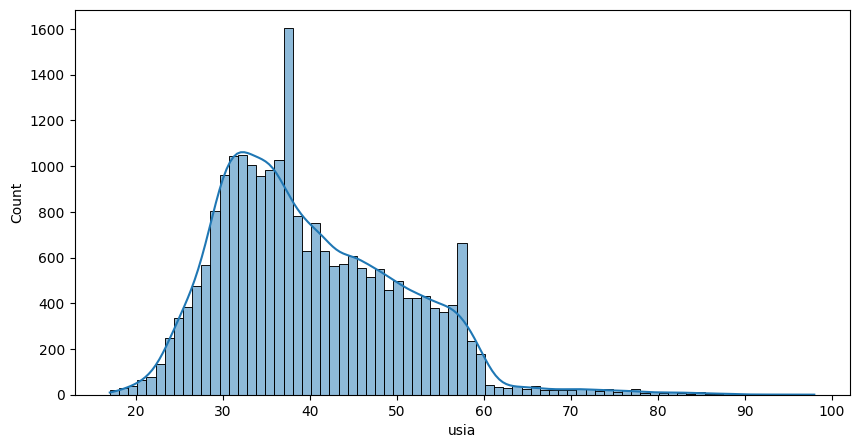

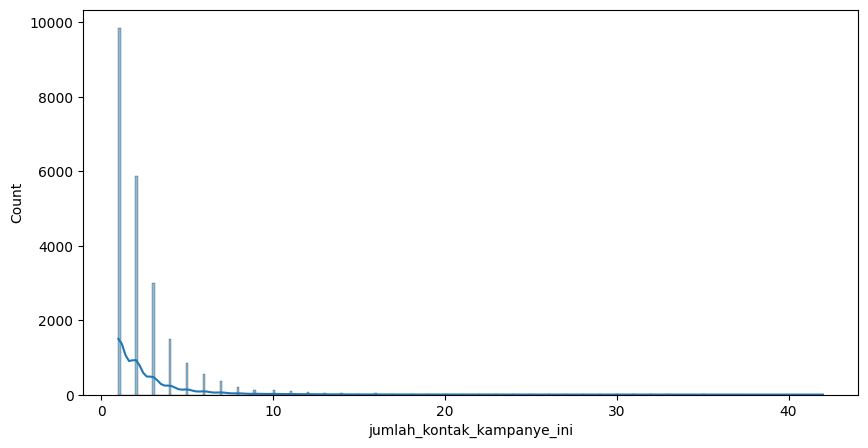

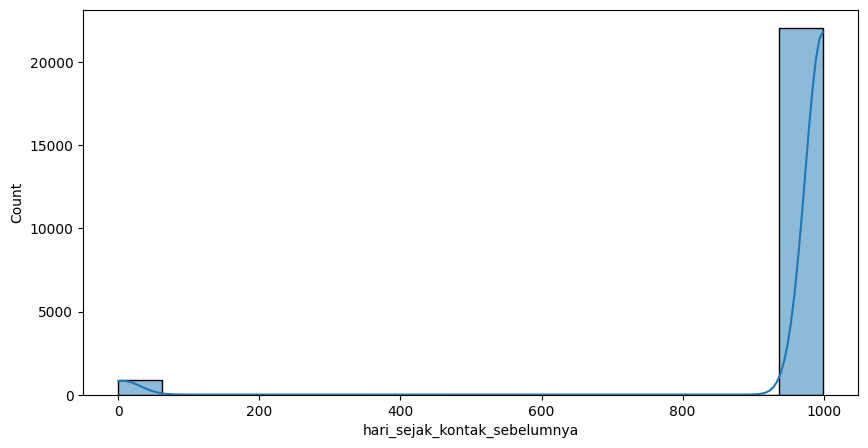

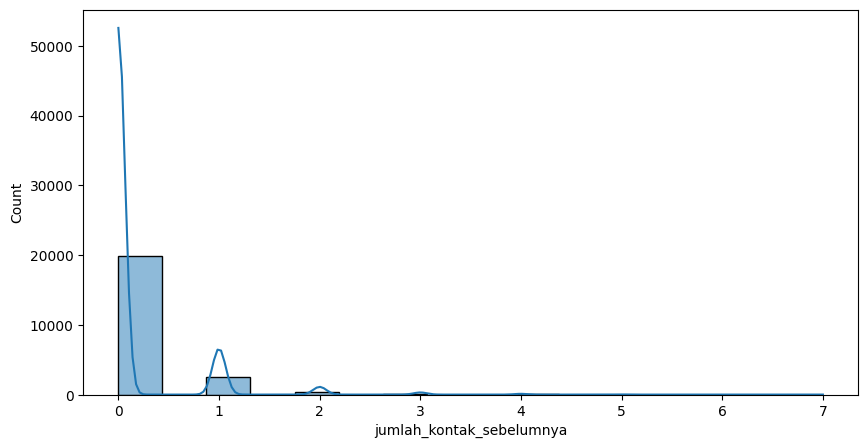

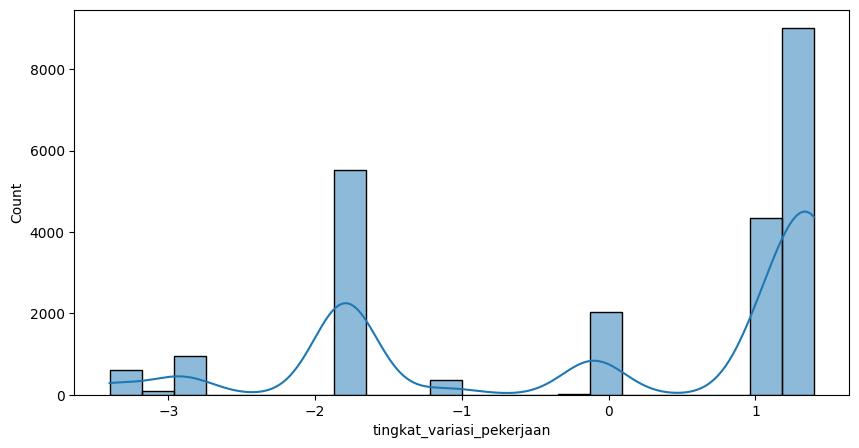

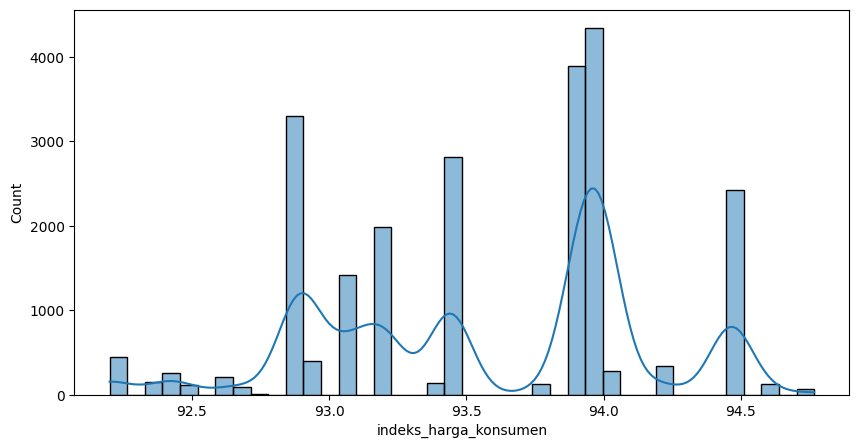

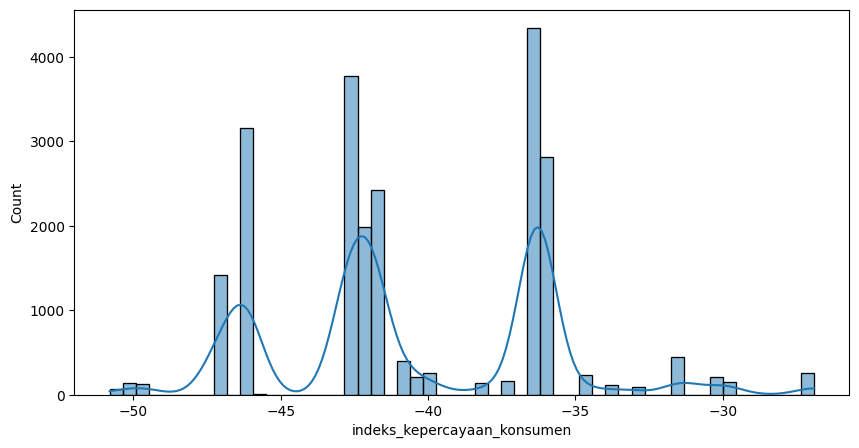

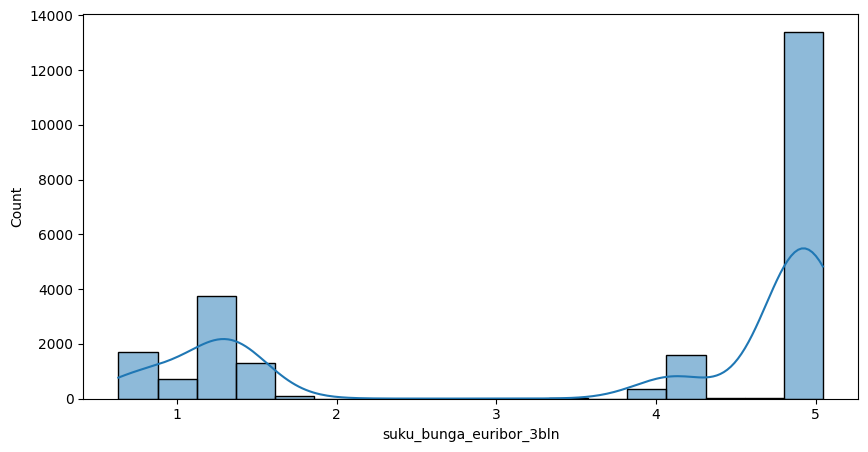

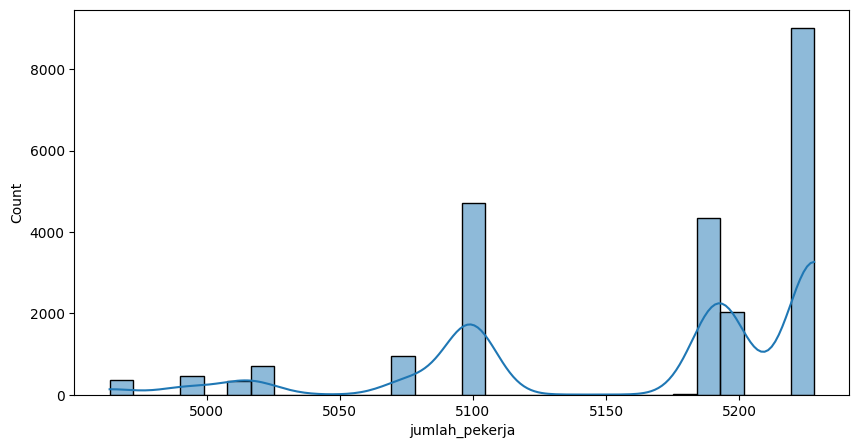

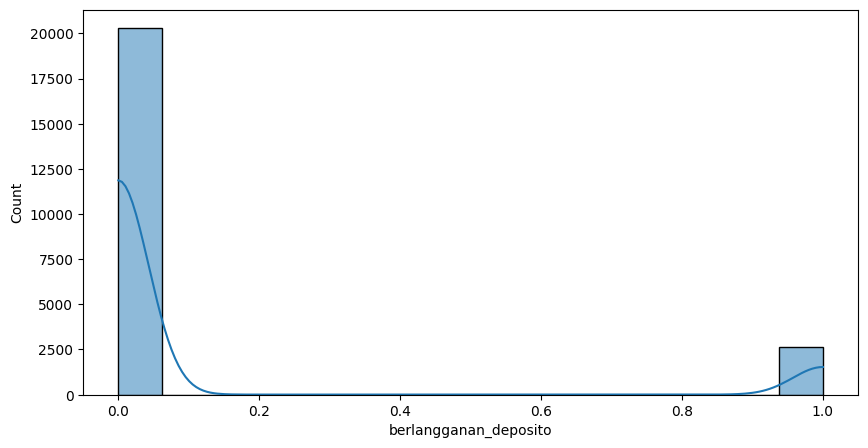

In [ ]:
for col in num_cols:
    plt.figure(figsize=(10, 5))
    sns.histplot(data=df_train_raw[col],kde=True)
    plt.show()

## CORRELATION FEATURES

<Axes: >

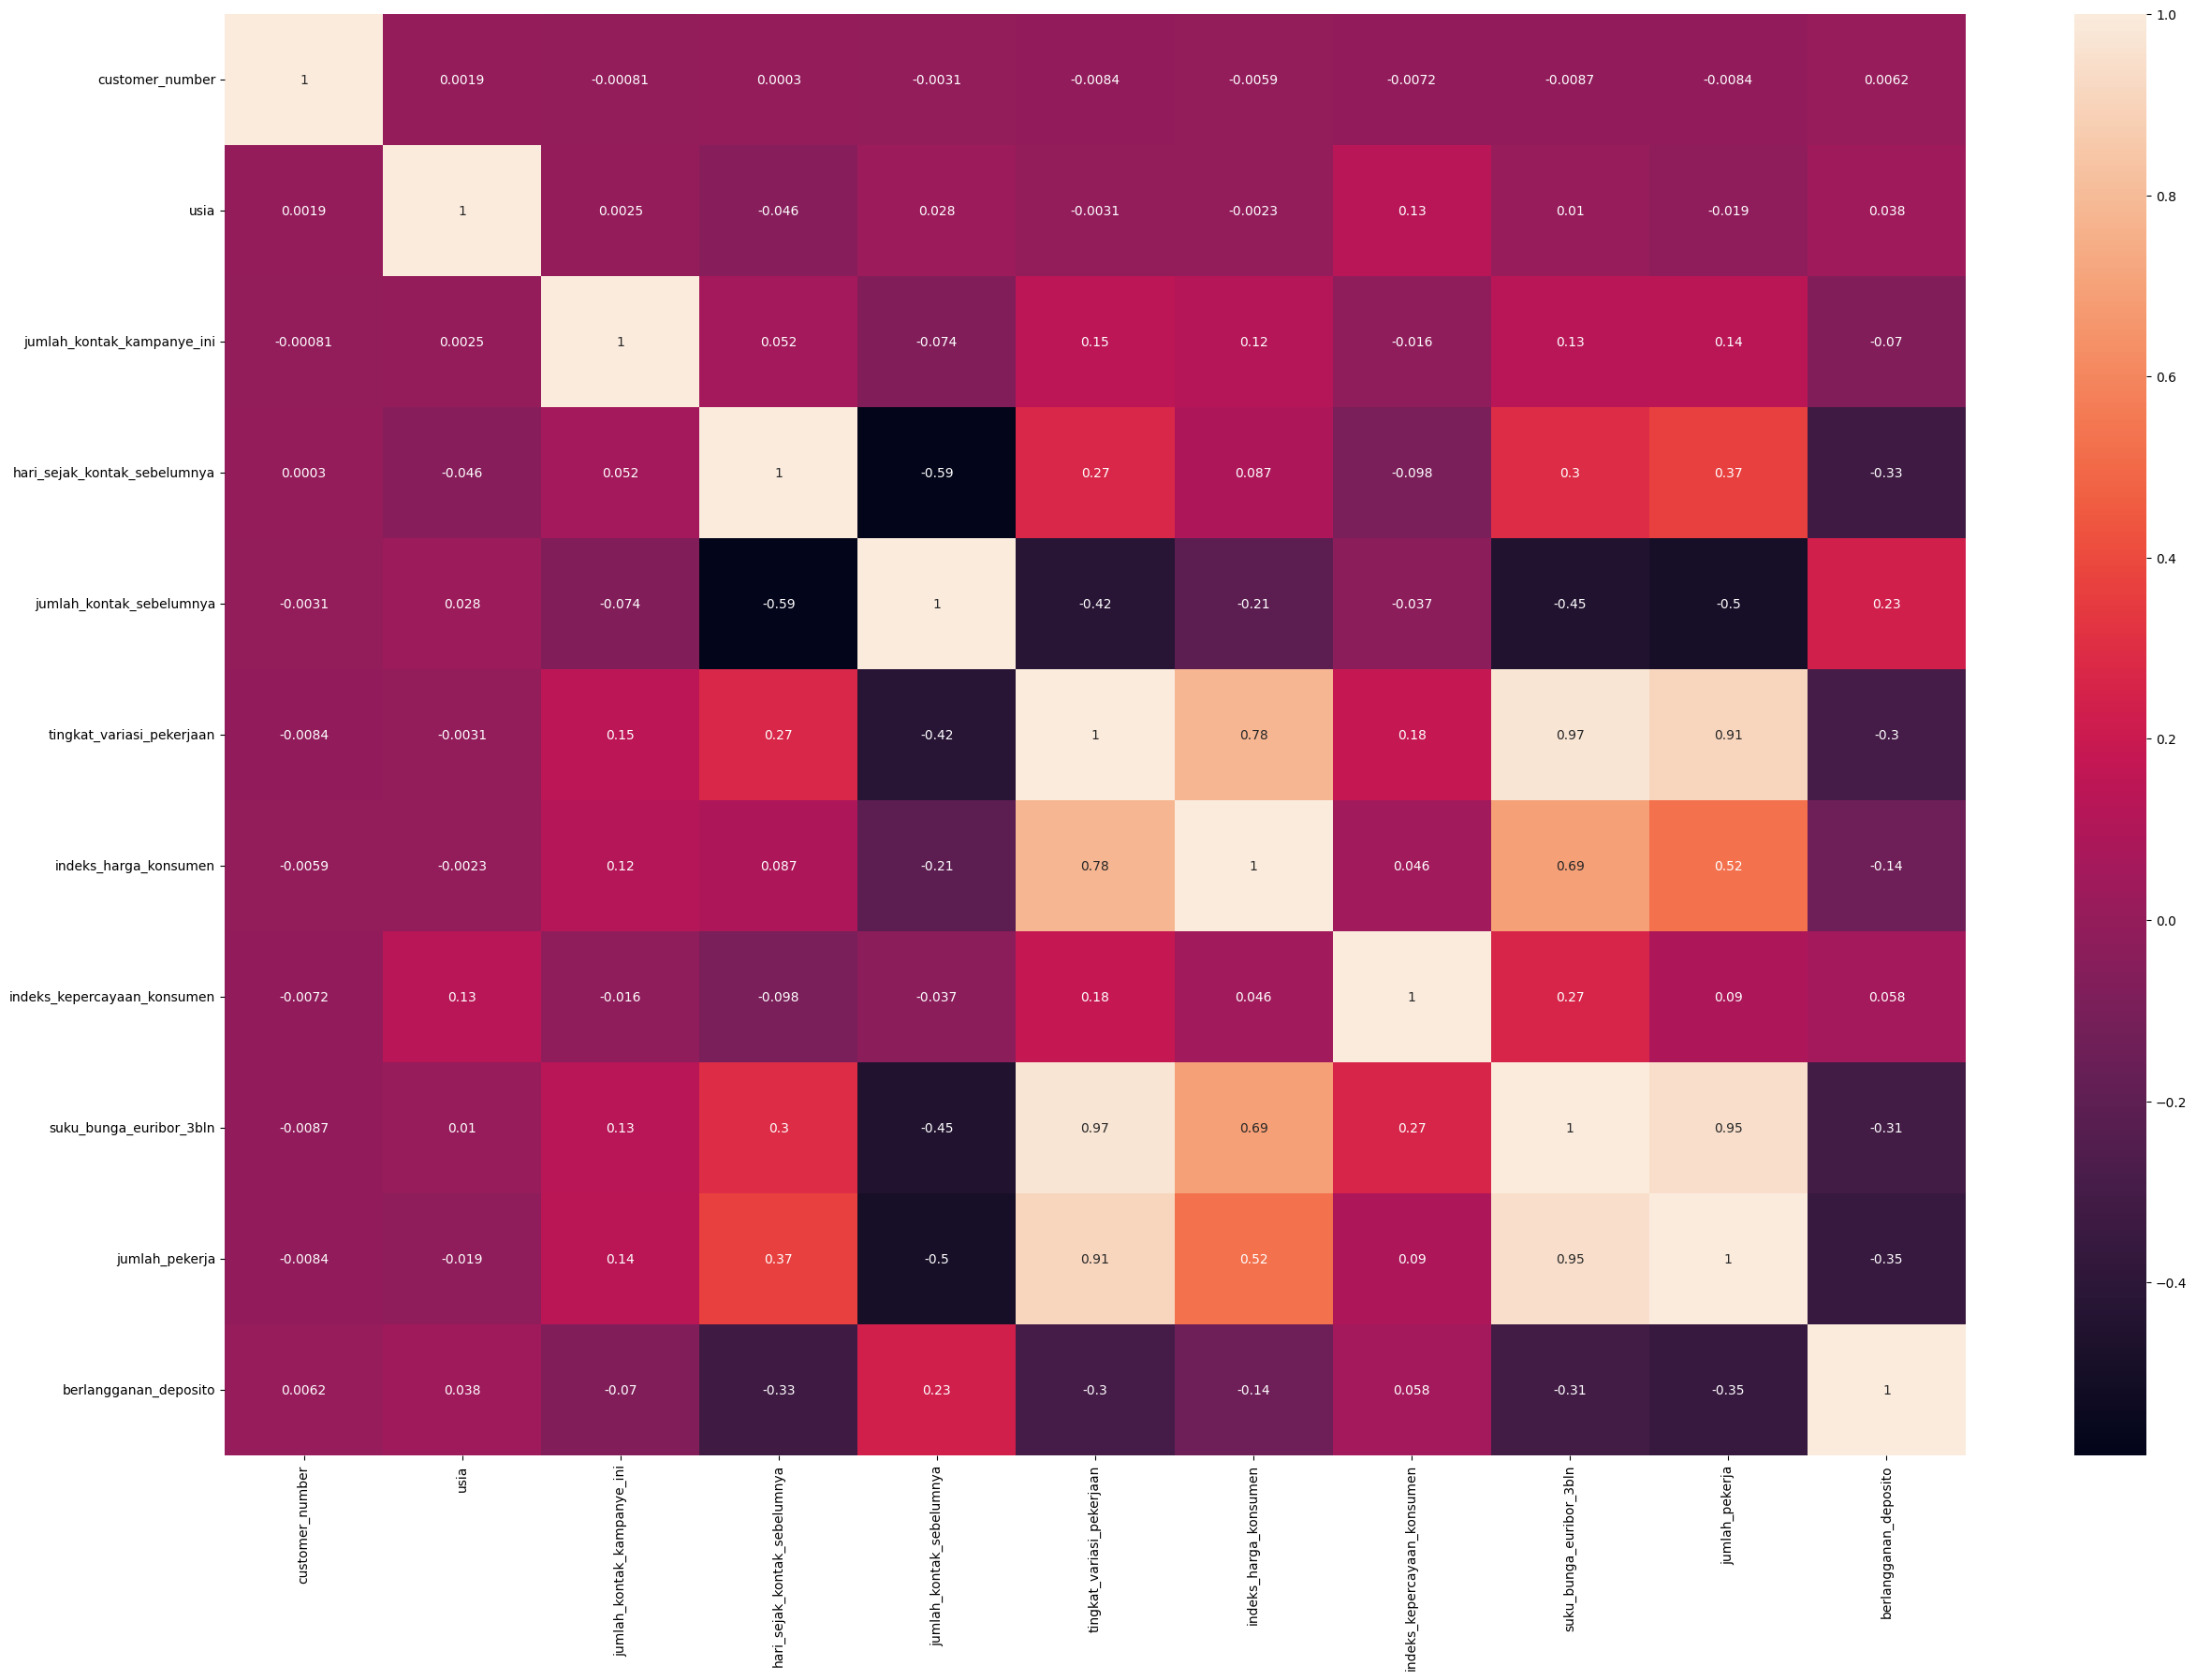

In [ ]:
plt.figure(figsize=(30, 20))
sns.heatmap(df_train_raw[num_cols].corr(), annot=True)

# DATA PREPROCESSING

## DATA CLEANSING

1. Nilai missiing (nULL) == nan --> pandas
2. Nilai duplikat
3. Outlier --> capping


In [ ]:
# Outliers Cleansing
for col in num_cols:
    Q1 = df_train_raw[col].quantile(0.25)
    Q3 = df_train_raw[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR


df_train_clean = df_train_raw
df_train_clean

,customer_number,usia,pekerjaan,status_perkawinan,pendidikan,gagal_bayar_sebelumnya,pinjaman_rumah,pinjaman_pribadi,jenis_kontak,bulan_kontak_terakhir,...,hari_sejak_kontak_sebelumnya,jumlah_kontak_sebelumnya,hasil_kampanye_sebelumnya,tingkat_variasi_pekerjaan,indeks_harga_konsumen,indeks_kepercayaan_konsumen,suku_bunga_euribor_3bln,jumlah_pekerja,pulau,berlangganan_deposito
0,531036,63,sosial media specialis,menikah,Pendidikan Tinggi,no,yes,no,cellular,jul,...,999,0,nonexistent,-1.7,94.215,-40.3,0.885,4991.6,Papua,1
1,999241,43,teknisi,menikah,Pendidikan Tinggi,no,yes,no,cellular,nov,...,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,Sulawesi,0
2,995002,29,sosial media specialis,lajang,Pendidikan Tinggi,no,yes,yes,cellular,jul,...,999,0,nonexistent,1.4,93.918,-42.7,4.958,5228.1,Papua,0
3,932750,40,pekerja kasar,menikah,SMA,no,no,no,telephone,may,...,999,0,nonexistent,1.1,93.994,-36.4,4.859,5191.0,Sumatera,1
4,684699,40,sosial media specialis,lajang,Pendidikan Tinggi,no,no,no,cellular,aug,...,999,0,nonexistent,1.4,93.444,-36.1,4.964,5228.1,Bali,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22911,680377,32,teknisi,menikah,Diploma,no,yes,no,cellular,aug,...,999,0,nonexistent,1.4,93.444,-36.1,4.967,5228.1,Kalimantan,0
22912,505429,30,mahasiswa,lajang,Diploma,no,no,no,telephone,sep,...,999,0,nonexistent,-1.1,94.199,-37.5,0.880,4963.6,Bali,0
22913,308952,29,manajer,lajang,SMA,no,yes,no,cellular,jul,...,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,NTT,0
22914,865813,52,entrepreneur,menikah,Tidak Tamat SD,unknown,yes,no,telephone,jun,...,999,0,nonexistent,1.4,94.465,-41.8,4.960,5228.1,NTB,0


In [ ]:
df_train_clean['hari_sejak_kontak_sebelumnya'].value_counts()

,count
hari_sejak_kontak_sebelumnya,
999,22067
3,254
6,245
4,70
9,31
7,29
2,27
12,24
10,23


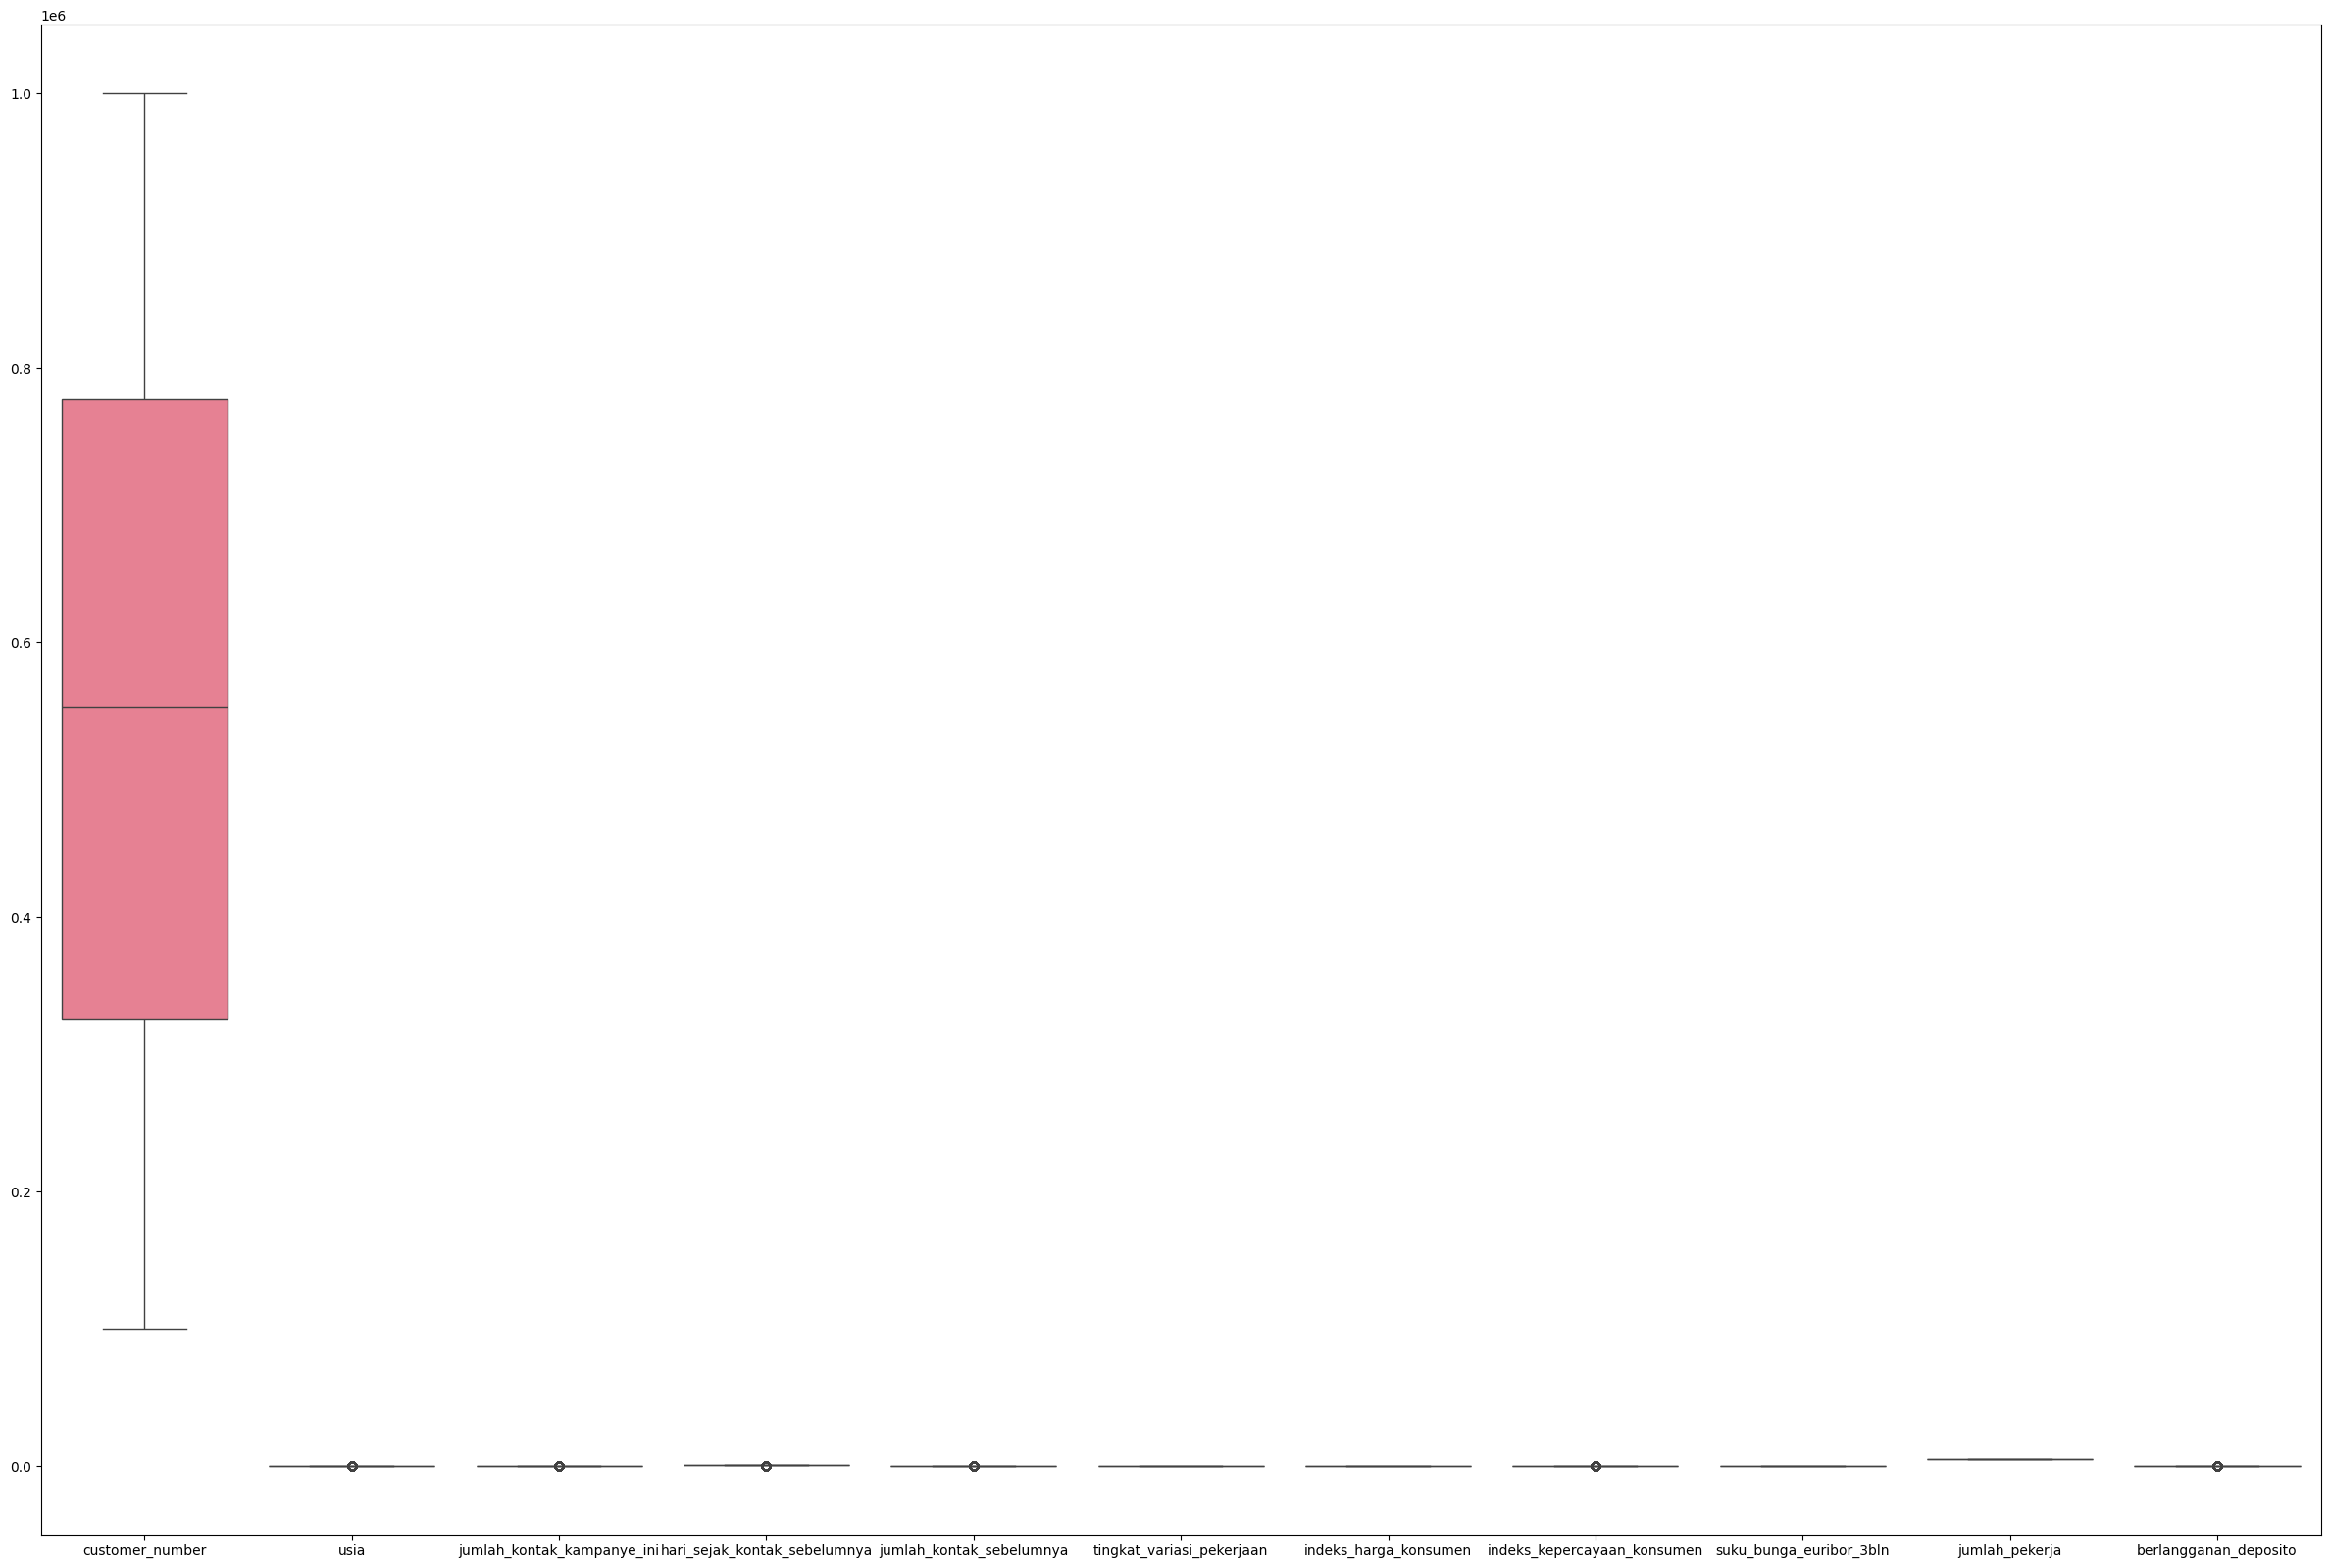

In [ ]:
# Cek Hasil Cleansing Outliers
plt.figure(figsize=(30, 20))
sns.boxplot(data=df_train_clean)
plt.show()

## DATA SPLITTING

1. Pisah Target dan Fitur

In [ ]:
# simpan customer number x val
customer_number = X_valid['customer_number']
X_valid = X_valid.drop(columns=['customer_number']) # Drop agar Sama dengan X dan Y train

# Split Data X dan Y
X = df_train_clean.drop(columns=['berlangganan_deposito','customer_number'])
y = df_train_clean['berlangganan_deposito']


In [ ]:
for col in X.select_dtypes(include='object').columns:
    X[col] = X[col].astype('category')

for col in X_valid.select_dtypes(include='object').columns:
    X_valid[col] = X_valid[col].astype('category')


2. Pisah Data Train dan Test

In [ ]:
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y,
#     test_size=0.05,
#     stratify=y,
#     random_state=42
# )

In [ ]:
# # Step 1: Split menjadi 90% train
# X_train, X_temp, y_train, y_temp = train_test_split(
#     X, y,
#     test_size=0.05,
#     stratify=y,
#     random_state=42
# )

# # Step 2: Split 10% eval jadi 5% lim dan 5% test
# X_lim, X_test, y_lim, y_test = train_test_split(
#     X_temp, y_temp,
#     test_size=0.50,
#     stratify=y_temp,
#     random_state=42
# )

# # Cek proporsi masing-masing
# print(f"Train size : {len(X_train)} ({len(X_train)/len(X):.2%})")
# # print(f"Limit size   : {len(X_lim)} ({len(X_lim)/len(X):.2%})")
# print(f"Test size  : {len(X_test)} ({len(X_test)/len(X):.2%})")

In [ ]:
# X_train2, X_lim2, y_train2, y_lim2 = train_test_split(
#         X_train, y_train,
#         test_size=0.05,
#         stratify=y_train,
#         random_state=42
#     )
# print(f"Train2 size     : {len(X_train2)} ({len(X_train2)/len(X_train):.2%})")
# print(f"lim2 size       : {len(X_lim2)} ({len(X_lim2)/len(X_train):.2%})")

In [ ]:
# # --- Step 2: Cast kolom kategori ke type 'category' ---
# for col in X_train.select_dtypes(include='object').columns:
#     X_train[col] = X_train[col].astype('category')
#     X_lim[col] = X_lim[col].astype('category')
#     X_test[col] = X_test[col].astype('category')
#     X_valid[col] = X_valid[col].astype('category')


#     # X_train2[col] = X_train2[col].astype('category')
#     # X_lim2[col] = X_lim2[col].astype('category')

3. Cek Dimensi Data

In [ ]:
# print(X_train.shape)
# # print(X_lim.shape)
# print(X_test.shape)

# print(y_train.shape)
# # print(y_lim.shape)
# print(y_test.shape)

In [ ]:
# y_train.value_counts()

In [ ]:
# y_test.value_counts()

# FEATURE ENGINEERING

1. scaling --> fitur numerik
2. encoding --> fitur kategorik
3. ekstraksi --> nambah fitur
4. dropping --> buang fitur

### BINNING FEATURES

In [ ]:
# Definisikan bins dan labels sesuai kategori
bins = [0, 17, 64, float("inf")]
labels = ['Remaja', 'Produktif', 'Lansia']

# Tambahkan kolom kategori usia ke X_train
X['kategori_usia'] = pd.cut(X["usia"], bins=bins, labels=labels, right=True)
X = X.drop(columns=['usia'], errors='ignore')


# # Tambahkan kolom kategori usia ke X_val
X_valid['kategori_usia'] = pd.cut(X_valid["usia"], bins=bins, labels=labels, right=True)
X_valid = X_valid.drop(columns=['usia'], errors='ignore')


# # Tambahkan kolom kategori usia ke X_test
# X_test["kategori_usia"] = pd.cut(X_test["usia"], bins=bins, labels=labels, right=True)
# X_test = X_test.drop(columns=['usia'], errors='ignore')

# # Tambahkan kolom kategori usia ke X_limit
# X_lim["kategori_usia"] = pd.cut(X_lim["usia"], bins=bins, labels=labels, right=True)
# X_lim = X_lim.drop(columns=['usia'], errors='ignore')

# X_lim2["kategori_usia"] = pd.cut(X_lim2["usia"], bins=bins, labels=labels, right=True)
# X_lim2 = X_lim2.drop(columns=['usia'], errors='ignore')

# X_train2['kategori_usia'] = pd.cut(X_train2["usia"], bins=bins, labels=labels, right=True)
# X_train2 = X_train2.drop(columns=['usia'], errors='ignore')

### FEATURES EXTRACTION

In [ ]:
X['rasio_kontak_aktif'] = X['jumlah_kontak_kampanye_ini'] / (X['jumlah_kontak_sebelumnya'] + 1e-6)
X_valid['rasio_kontak_aktif'] = X_valid['jumlah_kontak_kampanye_ini'] / (X_valid['jumlah_kontak_sebelumnya'] + 1e-6)
# X_test['rasio_kontak_aktif'] = X_test['jumlah_kontak_kampanye_ini'] / (X_test['jumlah_kontak_sebelumnya'] + + 1e-6)
# X_lim['rasio_kontak_aktif'] = X_lim['jumlah_kontak_kampanye_ini'] / (X_lim['jumlah_kontak_sebelumnya'] + 1e-6)

# X_train2['rasio_kontak_aktif'] = X_train2['jumlah_kontak_kampanye_ini'] / (X_train2['jumlah_kontak_sebelumnya'] + 1e-6)
# X_lim2['rasio_kontak_aktif'] = X_lim2['jumlah_kontak_kampanye_ini'] / (X_lim2['jumlah_kontak_sebelumnya'] + 1e-6)

In [ ]:
X['eubor_rendah'] = (X['suku_bunga_euribor_3bln'] < 2.0).astype(int)
# X_test['eubor_rendah'] = (X_test['suku_bunga_euribor_3bln'] < 2.0).astype(int)
X_valid['eubor_rendah'] = (X_valid['suku_bunga_euribor_3bln'] < 2.0).astype(int)
# X_lim['eubor_rendah'] = (X_lim['suku_bunga_euribor_3bln'] < 2.0).astype(int)

# X_train2['eubor_rendah'] = (X_train2['suku_bunga_euribor_3bln'] < 2.0).astype(int)
# X_lim2['eubor_rendah'] = (X_lim2['suku_bunga_euribor_3bln'] < 2.0).astype(int)

In [ ]:
threshold_prospek_pekerja = 5076.2
X['pekerja_kelompok_prospek_tinggi'] = (X['jumlah_pekerja'] <= threshold_prospek_pekerja).astype(int)
X_valid['pekerja_kelompok_prospek_tinggi'] = (X_valid['jumlah_pekerja'] <= threshold_prospek_pekerja).astype(int)
# X_test['pekerja_kelompok_prospek_tinggi'] = (X_test['jumlah_pekerja'] <= threshold_prospek_pekerja).astype(int)
# X_lim['pekerja_kelompok_prospek_tinggi'] = (X_lim['jumlah_pekerja'] <= threshold_prospek_pekerja).astype(int)

# X_train2['pekerja_kelompok_prospek_tinggi'] = (X_train2['jumlah_pekerja'] <= threshold_prospek_pekerja).astype(int)
# X_lim2['pekerja_kelompok_prospek_tinggi'] = (X_lim2['jumlah_pekerja'] <= threshold_prospek_pekerja).astype(int)

In [ ]:
X['eubor_and_pekerja'] = X['eubor_rendah'] * X['pekerja_kelompok_prospek_tinggi']
X_valid['eubor_and_pekerja'] = X_valid['eubor_rendah'] * X_valid['pekerja_kelompok_prospek_tinggi']
# X_test['eubor_and_pekerja'] = X_test['eubor_rendah'] * X_test['pekerja_kelompok_prospek_tinggi']
# X_lim['eubor_and_pekerja'] = X_lim['eubor_rendah'] * X_lim['pekerja_kelompok_prospek_tinggi']

# X_train2['eubor_and_pekerja'] = X_train2['eubor_rendah'] * X_train2['pekerja_kelompok_prospek_tinggi']
# X_lim2['eubor_and_pekerja'] = X_lim2['eubor_rendah'] * X_lim2['pekerja_kelompok_prospek_tinggi']

In [ ]:
X['skor_ekonomi_makro'] = (X['indeks_kepercayaan_konsumen'] + (X['indeks_harga_konsumen']) / 2)
X_valid['skor_ekonomi_makro'] = (X_valid['indeks_kepercayaan_konsumen'] + (X_valid['indeks_harga_konsumen']) / 2)
# X_test['skor_ekonomi_makro'] = (X_test['indeks_kepercayaan_konsumen'] + (X_test['indeks_harga_konsumen']) / 2)
# X_lim['skor_ekonomi_makro'] = (X_lim['indeks_kepercayaan_konsumen'] + (X_lim['indeks_harga_konsumen']) / 2)

# X_train2['skor_ekonomi_makro'] = (X_train2['indeks_kepercayaan_konsumen'] + (X_train2['indeks_harga_konsumen']) / 2)
# X_lim2['skor_ekonomi_makro'] = (X_lim2['indeks_kepercayaan_konsumen'] + (X_lim2['indeks_harga_konsumen']) / 2)

In [ ]:
X.drop(columns=['pekerja_kelompok_prospek_tinggi','jumlah_kontak_sebelumnya','pulau','eubor_rendah','jumlah_pekerja','indeks_kepercayaan_konsumen'], inplace=True)
X_valid.drop(columns=['pekerja_kelompok_prospek_tinggi','jumlah_kontak_sebelumnya','pulau','eubor_rendah','jumlah_pekerja','indeks_kepercayaan_konsumen'], inplace=True)
# X_test.drop(columns=['pekerja_kelompok_prospek_tinggi','jumlah_kontak_sebelumnya','pulau','eubor_rendah','jumlah_pekerja','indeks_kepercayaan_konsumen'], inplace=True)
# X_lim.drop(columns=['pekerja_kelompok_prospek_tinggi','jumlah_kontak_sebelumnya','pulau','eubor_rendah','jumlah_pekerja','indeks_kepercayaan_konsumen'], inplace=True)

# X_train2.drop(columns=['pekerja_kelompok_prospek_tinggi','jumlah_kontak_sebelumnya','pulau','eubor_rendah','jumlah_pekerja','indeks_kepercayaan_konsumen'], inplace=True)
# X_lim2.drop(columns=['pekerja_kelompok_prospek_tinggi','jumlah_kontak_sebelumnya','pulau','eubor_rendah','jumlah_pekerja','indeks_kepercayaan_konsumen'], inplace=True)

In [ ]:
X.shape

(22916, 19)

### SCALER DAN ENCODER

In [ ]:
# Scaler
std = StandardScaler() # Scaler
mm = MinMaxScaler() # Scaler
rbs = RobustScaler() # Scaler



### SCALING NUMERIK

#### X TRAIN & X TEST

In [ ]:
# Kolom Numerik Xtrain dan Xtest
# Pilih semua kolom numerik terlebih dahulu
num_cols_xtr = X.select_dtypes(include='number').columns
num_cols_xv = X_valid.select_dtypes(include='number').columns
# num_cols_xts = X_test.select_dtypes(include='number').columns
# num_cols_xli = X_lim.select_dtypes(include='number').columns
# num_cols_xli2 = X_lim2.select_dtypes(include='number').columns
# num_cols_xtr2 = X_train2.select_dtypes(include='number').columns


In [ ]:
X[num_cols_xtr] = std.fit_transform(X[num_cols_xtr]) # Train dan Scaling XTRAIN numerik
X_valid[num_cols_xv] = std.transform(X_valid[num_cols_xv]) # Scaling Xval numerik
# X_test[num_cols_xts] = std.transform(X_test[num_cols_xts]) # Scaling Xtest numerik
# X_lim[num_cols_xli] = std.transform(X_lim[num_cols_xli]) # Scaling Xlimit numerik
# X_lim2[num_cols_xli2] = std.transform(X_lim2[num_cols_xli2]) # Scaling Xlimit numerik
# X_train2[num_cols_xtr2] = std.fit_transform(X_train2[num_cols_xtr2]) # Scaling Xlimit numerik

### ENCODING KATEGORIK

In [ ]:
# # Kolom Kategori Berdasar X train dan X test
# cat_cols_xtr = X_train.select_dtypes(include=['category']).columns
# cat_cols_xv = X_valid.select_dtypes(include='category').columns
# cat_cols_xts = X_test.select_dtypes(include='category').columns
# # cat_cols_xli = X_lim.select_dtypes(include='category').columns

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22916 entries, 0 to 22915
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   pekerjaan                     22916 non-null  category
 1   status_perkawinan             22916 non-null  category
 2   pendidikan                    22916 non-null  category
 3   gagal_bayar_sebelumnya        22916 non-null  category
 4   pinjaman_rumah                22916 non-null  category
 5   pinjaman_pribadi              22916 non-null  category
 6   jenis_kontak                  22916 non-null  category
 7   bulan_kontak_terakhir         22916 non-null  category
 8   hari_kontak_terakhir          22916 non-null  category
 9   jumlah_kontak_kampanye_ini    22916 non-null  float64 
 10  hari_sejak_kontak_sebelumnya  22916 non-null  float64 
 11  hasil_kampanye_sebelumnya     22916 non-null  category
 12  tingkat_variasi_pekerjaan     22916 non-null  

In [878]:
 y.value_counts()

,count
berlangganan_deposito,
0,20302
1,2614


In [ ]:
X_valid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5729 entries, 0 to 5728
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   pekerjaan                     5729 non-null   category
 1   status_perkawinan             5729 non-null   category
 2   pendidikan                    5729 non-null   category
 3   gagal_bayar_sebelumnya        5729 non-null   category
 4   pinjaman_rumah                5729 non-null   category
 5   pinjaman_pribadi              5729 non-null   category
 6   jenis_kontak                  5729 non-null   category
 7   bulan_kontak_terakhir         5729 non-null   category
 8   hari_kontak_terakhir          5729 non-null   category
 9   jumlah_kontak_kampanye_ini    5729 non-null   float64 
 10  hari_sejak_kontak_sebelumnya  5729 non-null   float64 
 11  hasil_kampanye_sebelumnya     5729 non-null   category
 12  tingkat_variasi_pekerjaan     5729 non-null   fl

In [ ]:
# X_train[num_cols_xtr].corr()

# HYPERPARAMETER TUNING

### KEINO EXPERIMENT

In [ ]:
# # HYPERPARAMETER TUNING
# # ### KEINO EXPERIMENT
# # %%
# # Add print statements to debug shapes
# print(f"Shape of X_train before encoding: {X_train.shape}")
# print(f"Shape of y_train before encoding: {y_train.shape}")

# X_train_enc = X_train.copy()

# cat_cols_enc = X_train_enc.select_dtypes(include='category').columns
# num_cols_enc = X_train_enc.select_dtypes(include='number').columns

# le_dict = {}

# cat_cols = X_train.select_dtypes(include=['object', 'category']).columns
# num_cols = X_train.select_dtypes(include='number').columns

# # Simpan hasil encoding per kolom
# for col in cat_cols:
#     le = LabelEncoder()
#     X_train_enc[col] = le.fit_transform(X_train[col])
#     le_dict[col] = le

# # === SMOTE di data encoded ===
# smote = SMOTE(random_state=42)
# X_res_enc, y_res = smote.fit_resample(X_train_enc, y_train)

# # Konversi hasil X_res_enc ke DataFrame untuk rekonstruksi
# X_res_enc = pd.DataFrame(X_res_enc, columns=X_train_enc.columns)

# # === Kembalikan kolom kategori ke bentuk aslinya ===
# X_res_final = X_res_enc.copy()
# for col in cat_cols:
#     le = le_dict[col]
#     X_res_final[col] = le.inverse_transform(X_res_enc[col].astype(int))
#     X_res_final[col] = X_res_final[col].astype('category')


In [ ]:
# --- Step 3: Tentukan list index kolom kategorikal ---
cat_features = X.select_dtypes(include='category').columns.tolist()
cat_features_1 = X_valid.select_dtypes(include='category').columns

In [879]:
from collections import Counter
counter = Counter(y)
total = sum(counter.values())
class_weights = {k: total/v for k, v in counter.items()}
weights_list = [class_weights[cls] for cls in sorted(class_weights.keys())]
print("Class weights:", weights_list)

Class weights: [1.1287557876071324, 8.76664116296863]


In [872]:
# 3. Buat dan train model CatBoost dengan class_weights

# Explicitly cast categorical columns to 'category' dtype
# This is important because CatBoost relies on column types for automatic handling
# even when 'cat_features' is specified.


model = CatBoostClassifier(
    iterations=800,
    learning_rate=0.03,
    loss_function='Logloss',
    depth=6,
    # Ensure cat_features_1 correctly reflects the categorical columns in the current X
    cat_features=cat_features,
    class_weights=weights_list,
    early_stopping_rounds=50,
    verbose=100,
    l2_leaf_reg=5,
    eval_metric='AUC',
    random_seed=42
)

model.fit(
    X, y


)

y_pred = model.predict(X_valid)
y_probs = model.predict_proba(X_valid)[:, 1]

submission = pd.DataFrame({
    'customer_number': customer_number,
    'berlangganan_deposito': y_probs
})

submission.to_csv('DCM_DMU_2025_Model_Lemon Soda1.csv', index=False)
print("DCM_DMU_2025_Model_Lemon Soda.csv berhasil")

0:	total: 194ms	remaining: 2m 35s
100:	total: 9.28s	remaining: 1m 4s
200:	total: 13.7s	remaining: 40.8s
300:	total: 20s	remaining: 33.2s
400:	total: 25.2s	remaining: 25.1s
500:	total: 32.4s	remaining: 19.3s
600:	total: 38.3s	remaining: 12.7s
700:	total: 45.7s	remaining: 6.45s
799:	total: 51.5s	remaining: 0us
DCM_DMU_2025_Model_Lemon Soda.csv berhasil


In [ ]:
# feature_importance = model.get_feature_importance(prettified=True)

# # # Tampilkan 20 fitur teratas
# feature_importance.head(20)

# # Atau visualisasikan
# plt.figure(figsize=(10, 6))
# plt.barh(feature_importance['Feature Id'][:23], feature_importance['Importances'][:23])
# plt.gca().invert_yaxis()
# plt.title('Top 20 Feature Importance')
# plt.show()

In [ ]:
# feature_importance.head(23)

#### PARAMS TUNING

#### ANALISA FITUR IMPORTANCE

In [ ]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# sns.kdeplot(df_train_clean[df_train_clean['berlangganan_deposito'] == 0]['suku_bunga_euribor_3bln'], label='Label 0')
# sns.kdeplot(df_train_clean[df_train_clean['berlangganan_deposito'] == 1]['suku_bunga_euribor_3bln'], label='Label 1')
# plt.title("Distribusi Suku Bunga EURIBOR 3 Bulan")
# plt.legend()
# plt.show()


In [ ]:
# from sklearn.metrics import roc_auc_score
# auc = roc_auc_score(df_train_clean['berlangganan_deposito'], -df_train_clean['suku_bunga_euribor_3bln'])
# print(f"AUC: {auc:.2f}")


In [ ]:
# sns.kdeplot(df_train_clean[df_train_clean['berlangganan_deposito'] == 0]['jumlah_pekerja'], label='Label 0')
# sns.kdeplot(df_train_clean[df_train_clean['berlangganan_deposito'] == 1]['jumlah_pekerja'], label='Label 1')
# plt.title("Distribusi Jumlah Pekerja")
# plt.legend()
# plt.show()

In [ ]:
# pekerjaan_summary = df_train_clean.groupby('jumlah_pekerja')['berlangganan_deposito'].value_counts(normalize=True).unstack()
# pekerjaan_summary.plot(kind='bar', stacked=True, figsize=(12,6), colormap='coolwarm')
# plt.title('Proporsi Label 0 dan 1 untuk Setiap Jumlah Pekerja')
# plt.ylabel('Proporsi')
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()


In [ ]:
# auc = roc_auc_score(df_train_clean['berlangganan_deposito'], -df_train_clean['jumlah_pekerja'])
# print(f"AUC: {auc:.2f}")


In [ ]:
# import shap

# # Ambil model CatBoost dari ensemble
# cat_model = model

# # Buat explainer
# explainer = shap.TreeExplainer(cat_model)

# # Hitung SHAP values untuk X_val
# shap_values = explainer.shap_values(X_test)

# # Visualisasi summary plot
# shap.summary_plot(shap_values, X_test)


In [ ]:

# # Hitung nilai penting SHAP (rata-rata absolut tiap fitur)
# mean_shap = np.abs(shap_values).mean(axis=0)

# # Buat tabel
# shap_table = pd.DataFrame({
#     'Fitur': X_test.columns,
#     'Mean |SHAP Value|': mean_shap
# }).sort_values(by='Mean |SHAP Value|', ascending=False)

# # Tampilkan top 15 fitur
# print(shap_table.head(28).to_string(index=False))


In [ ]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# # Pilih fitur yang relevan secara tema
# fitur_ekonomi = X_train[num_cols_xtr]

# # Hitung korelasi
# corr = fitur_ekonomi.corr()

# # Visualisasi korelasi
# plt.figure(figsize=(6, 4))
# sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
# plt.title('Korelasi antar Fitur Ekonomi')
# plt.show()


In [ ]:
# corr

In [ ]:
# kontak_summary = df_train_clean.groupby('jumlah_kontak_kampanye_ini')['berlangganan_deposito'].value_counts(normalize=True).unstack()
# kontak_summary.plot(kind='bar', stacked=True, figsize=(12,6), colormap='coolwarm')
# plt.title('Proporsi Jumlah Kontak Sebelumnya')
# plt.ylabel('Proporsi')
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()

In [ ]:
# auc = average_precision_score(df_train_clean['berlangganan_deposito'], np.log1p(df_train_clean['jumlah_kontak_kampanye_ini']))
# print(f"AUC: {auc:.2f}")
